<a href="https://colab.research.google.com/github/ardatanriverdi/MLProjects/blob/main/Session2_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from sklearn.tree import export_graphviz
import graphviz




In [ ]:
df = pd.read_csv('sample_data/heart_attack.csv')
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [ ]:
x = df[['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']]
y = df['Result']
y = y.replace({'Positive':1, 'Negative':0})
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)


In [ ]:
# model = LogisticRegression(max_iter=1000)
# model.fit(x_train, y_train)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(x_test)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9772727272727273


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[ 99   2]
 [  4 159]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.96      0.98      0.97       101
    positive       0.99      0.98      0.98       163

    accuracy                           0.98       264
   macro avg       0.97      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



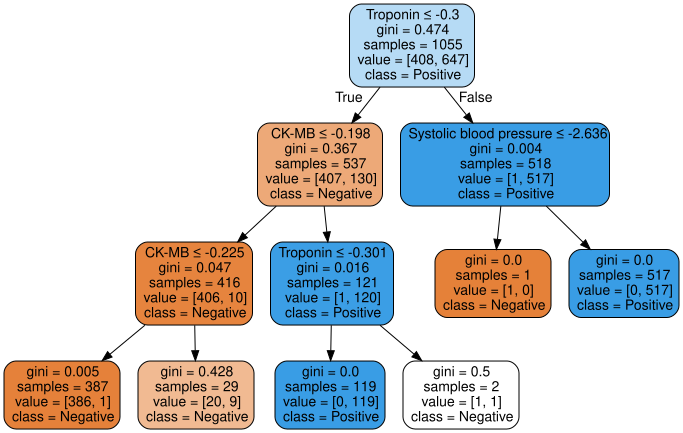

In [ ]:
# draw the decision tree

dot_data = export_graphviz(model, out_file=None, feature_names=x.columns, class_names=['Negative', 'Positive'], filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph